In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential, layers, models
import cv2
import matplotlib.pyplot as plt
import numpy
from pathlib import Path
import pandas as pd
from config import find_project_root

### Create an image preprocessing pipeline

In [10]:
project_root = find_project_root(Path.cwd())
train_dir = project_root / "data" / "train" / "train"
test_dir = project_root / "data" / "test" / "test"

In [11]:
def create_train_val_split(train_dir=train_dir, test_dir=test_dir, val_split=0.2, img_size=(32, 32, 3), batch_size=32, seed=42):
    """Splits the data into train and validation samples"""
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=val_split,
        subset="training",
        seed=seed,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='int'
    )

    val_from_train = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        validation_split=val_split,
        subset='validation',
        seed=seed,
        image_size=img_size,
        batch_size = batch_size,
        label_mode='int'
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=img_size,
        batch_size=batch_size,
        label_mode="int"
    )

    return train_ds, val_from_train, test_ds

In [12]:
# Fit the data into Neural Network
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),

    layers.Dense(10, activation='softmax')
])

c:\Users\dparh\Documents\GitHub\Image-Recognition-Network\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer='adam',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,034 (1.38 MB)

 Trainable params: 361,034 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# pre process the labels correctly
import pandas as pd

labels_df = pd.read_csv(project_root / "data" / "trainLabels.csv")

labels_df['id'] = labels_df['id'].astype(str)
labels_df['image_path'] = labels_df['id'].map(lambda x: str(train_dir / f"{x}.png"))

df = labels_df[['image_path', 'label']].dropna().reset_index(drop=True)
df.head(5)

df.to_csv("train_df_with_labels.csv")

In [16]:
label_to_idx = {label: i for i, label in enumerate(sorted(df['label'].unique()))}
df['label_idx'] = df['label'].map(label_to_idx)

def load_image(path, label):
    img = tf.io.read_file(path) # open image object
    img = tf.image.decode_png(img, channels=3)  # decode the image(!3 channels since i am dealing with RGB images)
    img = tf.image.resize(img, (32,32)) # resize to (32,32) since that is what my model will read
    img = tf.cast(img, tf.float32) / 255.0  #normalize
    return img, label   # return image and the label of the corrsponding image

# Create a Tensorflow dataset to conveniently fit the data
ds = tf.data.Dataset.from_tensor_slices(
    (df['image_path'].values, df['label_idx'].values)
)

ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [32]:
from sklearn.model_selection import train_test_split

X = df["image_path"].values
y = df["label_idx"].values

X_train, X_val, y_train, y_val = train_test_split(
    X.to_numpy(),
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 55s 43ms/step - accuracy: 0.4324 - loss: 1.5423 - val_accuracy: 0.5454 - val_loss: 1.2585
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.5828 - loss: 1.1748 - val_accuracy: 0.6369 - val_loss: 1.0262
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.6434 - loss: 1.0135 - val_accuracy: 0.6828 - val_loss: 0.9007
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6865 - loss: 0.8978 - val_accuracy: 0.6919 - val_loss: 0.8766
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.7215 - loss: 0.8002 - val_accuracy: 0.7269 - val_loss: 0.7753
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.7492 - loss: 0.7178 - val_accuracy: 0.7487 - val_loss: 0.7086
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.7777 - loss: 0.6423 - val_accuracy: 0.7685 - val_loss: 0.6564
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.8000 -

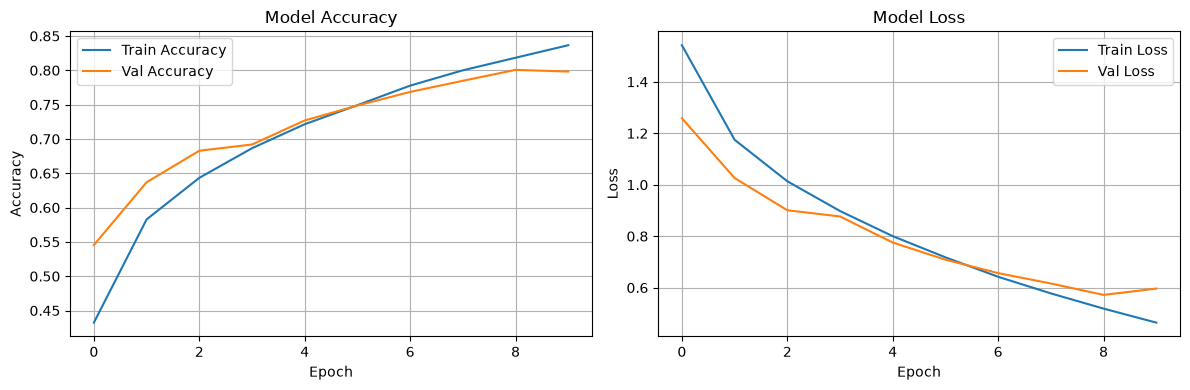

In [28]:
# plot the learning curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step


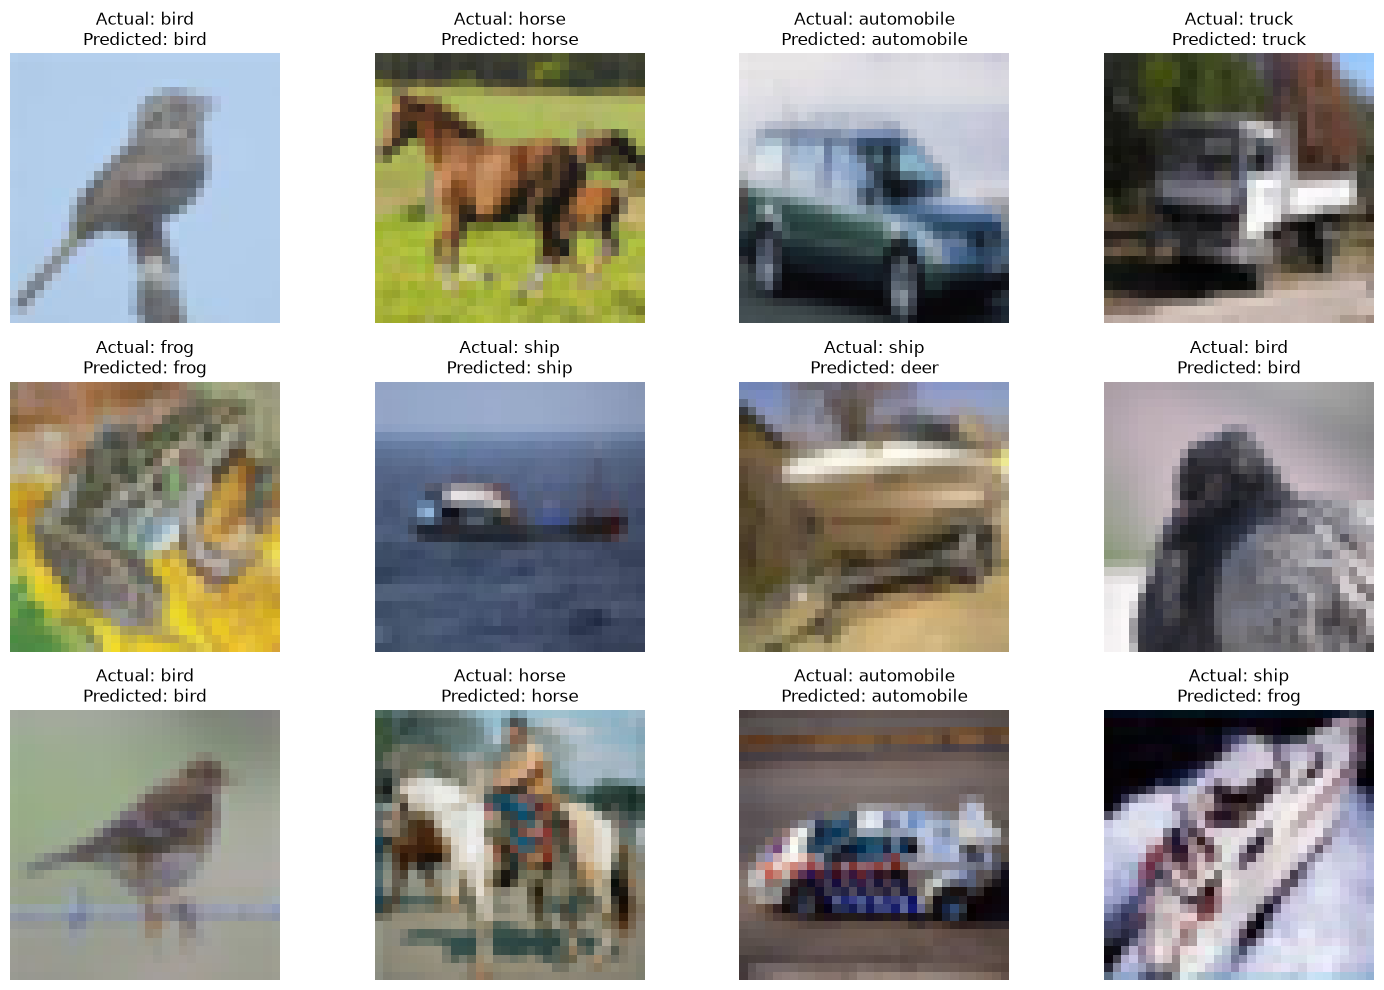

In [33]:
# Get predictions on validation set
predictions = model.predict(test_ds)
predicted_labels = numpy.argmax(predictions, axis=1)

# Create reverse mapping from index to label
idx_to_label = {v: k for k, v in label_to_idx.items()}

# Plot some predictions
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i in range(12):
    img = cv2.imread(X_val[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    actual_label = idx_to_label[y_val[i]]
    predicted_label = idx_to_label[predicted_labels[i]]
    
    axes[i].imshow(img)
    axes[i].set_title(f'Actual: {actual_label}\nPredicted: {predicted_label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [34]:
model.save("image_classification_model.h5")